Când auzim despre AI, ne gândim imediat la ChatGPT, roboți sau imagini generate pe calculator. Pentru a înțelege cum funcționează, trebuie să privim AI-ul ca pe o serie de domenii incluse unele în altele:

1. **Inteligența Artificială (AI):** Conceptul umbrelă. Orice sistem informatic capabil să imite inteligența umană. La extremitatea teoretică a acestui domeniu se află **AGI (Artificial General Intelligence)** – un sistem ipotetic viitor care ar avea capacitatea să înțeleagă și să învețe orice sarcină intelectuală la fel de bine ca un om.
2. **Machine Learning (ML):** Subdomeniul practic al AI-ului în care calculatorul învață din *date* în loc să fie programat cu reguli stricte. Aici se află algoritmul pe care îl vom programa astăzi.
3. **Deep Learning (Rețele Neuronale):** O ramură a ML-ului inspirată de arhitectura creierului uman. Folosește straturi de "neuroni artificiali" pentru a rezolva probleme foarte complexe (ex: recunoaștere facială, traducere simultană).
4. **Generative AI (AI Generativ):** Vârful de lance din prezent (ex: ChatGPT, Gemini, Midjourney). Sunt modele bazate pe rețele neuronale masive care nu doar analizează informații, ci sunt capabile să **genereze** conținut complet nou și original.

### Programarea Clasică vs. Machine Learning
Astăzi vom construi fundația voastră în acest univers, începând cu nivelul de Machine Learning.

În programarea clasică scrii **regulile** (`if`, `for`), introduci **datele**, iar calculatorul îți dă **răspunsurile**.
În Machine Learning, inversăm procesul. Îi dăm calculatorului **datele** și **răspunsurile corecte** (istoricul), iar el trebuie să calculeze și să descopere singur **regulile** (tiparele). Aceste reguli deduse matematic formează ceea ce numim un **Model de ML**.

## 2. Teoria din spatele Regresiei Liniare

### Intuiția
Imaginați-vă un grafic cu puncte (scatter plot) care arată venitul mediu al unei familii pe axa X și valoarea casei pe axa Y. Regresia Liniară trage **cea mai bună linie dreaptă** printre aceste puncte. 

Odată ce avem această linie, dacă vine o familie nouă cu un venit pe care nu l-am mai văzut, ne uităm pe linie și putem **prezice** cât va costa casa lor.

### Matematica (Simplificată)
Ecuația unei drepte învățate la matematică este:
$$y = mx + n$$

În Machine Learning, notația standard folosește "ponderi" (weights - $w$) și un "termen liber" (bias - $b$):
$$\hat{y} = w \cdot x + b$$

* $x$ = **Feature** (Funcționalitatea / Datele de intrare, ex: Venitul familiei).
* $\hat{y}$ = **Predicția** modelului (Valoarea estimată a casei).
* $w$ = **Ponderea** (Cât de mult influențează venitul prețul casei - panta dreptei).
* $b$ = **Bias-ul** (De unde începe linia pe axa Y, independent de venit).

Modelul nostru de ML va porni cu valori la întâmplare pentru $w$ și $b$. 

### Cum învață modelul? (Funcția de Pierdere)
Cum știe calculatorul că a găsit "cea mai bună linie"? Calculează **Eroarea Pătratică Medie (MSE - Mean Squared Error)**. 
Pentru fiecare punct real din datele noastre ($y$), măsoară distanța până la linia prezisă ($\hat{y}$), o ridică la pătrat (pentru a elimina valorile negative și a penaliza erorile mari) și face media.

$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

Scopul algoritmului în timpul "antrenării" (training) este să modifice $w$ și $b$ astfel încât această eroare ($MSE$) să devină cât mai aproape de zero.

## 3. Pașii creării unui Model în Scikit-Learn

Indiferent de algoritm (regresie liniară, rețele neuronale simple, arbori de decizie), în `scikit-learn` vom urma aproape mereu acești 4 pași:

1. **Pregătirea datelor:** Separăm datele în `X` (ce știm / cauzele) și `y` (ce vrem să prezicem / efectul).
2. **Train/Test Split:** Împărțim datele în două bucăți. Un set de "Antrenare" (pe care modelul învață) și un set de "Testare" (pe care îl ținem ascuns pentru a-i da un examen la final). Niciodată nu testăm modelul pe datele pe care le-a văzut deja, pentru că ar putea pur și simplu să le memoreze.
3. **Inițializarea și Antrenarea:** Creăm modelul și apelăm funcția `.fit(X_train, y_train)`.
4. **Predicția și Evaluarea:** Folosim `.predict(X_test)` și comparăm rezultatele cu realitatea.

In [1]:
# 4. Exemplu Practic: Regresia Liniară pe datele "housing.csv"

# Importăm bibliotecile necesare
import pandas as pd
import matplotlib.pyplot as plt

# Din scikit-learn importăm algoritmul și uneltele de evaluare
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 1. Încărcăm datele
df = pd.read_csv("housing.csv")

# Ne asigurăm că nu avem valori lipsă (curățare rudimentară)
df = df.dropna()

# Definim X (Feature-ul - Venitul) și y (Target-ul - Valoarea casei)
# ATENȚIE: scikit-learn cere ca X să fie un tabel 2D (de aceea folosim [[ ]]), iar y un array 1D
X = df[["median_income"]] 
y = df["median_house_value"]

# 2. Împărțim datele: 80% pentru antrenare (învățare), 20% pentru testare (examen)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Date de antrenare: {len(X_train)} rânduri")
print(f"Date de testare: {len(X_test)} rânduri")

Date de antrenare: 16346 rânduri
Date de testare: 4087 rânduri


In [2]:
# 3. Creăm și Antrenăm modelul
model = LinearRegression()

# Aici se întâmplă matematica din spate (găsirea lui w și b pentru a minimiza eroarea)
model.fit(X_train, y_train)

# Putem să ne uităm "sub capotă" să vedem ce a învățat
w = model.coef_[0]
b = model.intercept_

print(f"Ecuația dreptei găsite: Preț = {w:.2f} * Venit + {b:.2f}")

# 4. Facem predicții pe datele pe care modelul NU le-a mai văzut (Examenul)
predictii = model.predict(X_test)

# Măsurăm cât a greșit în medie
eroare_mse = mean_squared_error(y_test, predictii)
# Extragem radicalul pentru a avea eroarea în dolari (RMSE)
eroare_medie_dolari = eroare_mse ** 0.5 

print(f"În medie, modelul nostru greșește cu aproximativ {eroare_medie_dolari:.2f} dolari.")

Ecuația dreptei găsite: Preț = 41751.96 * Venit + 45035.23
În medie, modelul nostru greșește cu aproximativ 84976.53 dolari.


### Cum interpretăm eroarea?

Modelul nostru greșește cu **~85.000 $** în medie. Este bine sau rău?

Cel mai simplu **model de referință** (baseline) este să prezici mereu **media** tuturor caselor (~206.000 $), fără să te uiți la niciun feature. Acel model ar greși cu ~115.000 $.

| Model | RMSE |
|-------|------|
| Baseline (mereu media) | ~115.000 $ |
| Regresia noastră (1 feature) | ~85.000 $ |

Regresia este mai bună decât baseline-ul, dar eroarea rămâne mare — un semn că un singur feature (`median_income`) nu explică totul. Vom vedea în exerciții că adăugând mai mulți features eroarea scade.

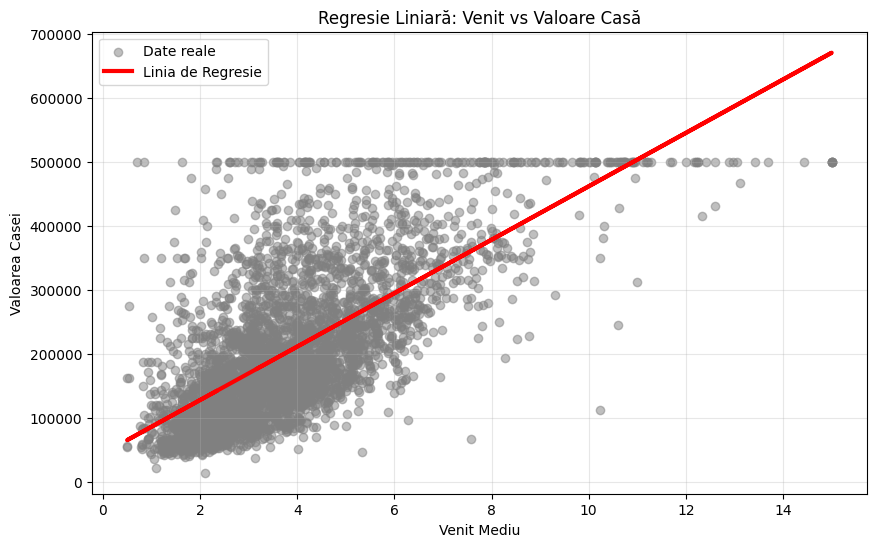


Pentru o zonă cu venitul 6.5, modelul prezice o valoare a casei de: 316422.95 dolari.


In [3]:
# 5. Vizualizarea rezultatului
plt.figure(figsize=(10, 6))

# Desenăm punctele REALE din setul de testare (cu gri)
plt.scatter(X_test, y_test, color='gray', alpha=0.5, label='Date reale')

# Desenăm LINIA (predicțiile modelului nostru - cu roșu)
plt.plot(X_test, predictii, color='red', linewidth=3, label='Linia de Regresie')

plt.title('Regresie Liniară: Venit vs Valoare Casă')
plt.xlabel('Venit Mediu')
plt.ylabel('Valoarea Casei')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Test cu un venit complet nou introdus de noi:
venit_nou = pd.DataFrame({"median_income": [6.5]}) # Venit de 6.5
pret_estimat = model.predict(venit_nou)
print(f"\nPentru o zonă cu venitul 6.5, modelul prezice o valoare a casei de: {pret_estimat[0]:.2f} dolari.")

### Graficul reziduurilor

Un **reziduu** = valoarea reală − predicție. Dacă modelul e bun, reziduurile ar trebui să fie distribuite aleator în jurul lui 0 (fără pattern). Dacă există un pattern, înseamnă că modelul nu a capturat ceva important din date.

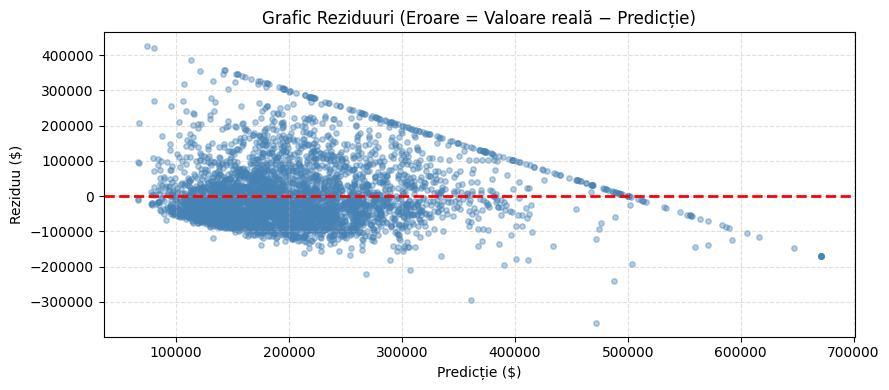

In [4]:
# Grafic reziduuri
reziduuri = y_test - predictii

plt.figure(figsize=(9, 4))
plt.scatter(predictii, reziduuri, alpha=0.4, color='steelblue', s=15)
plt.axhline(0, color='red', linewidth=2, linestyle='--')
plt.title('Grafic Reziduuri (Eroare = Valoare reală − Predicție)')
plt.xlabel('Predicție ($)')
plt.ylabel('Reziduu ($)')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# Dacă reziduurile formează un clopot simetric în jurul lui 0 → modelul e OK
# Dacă există o formă de evantai / curbă → avem o problemă sistematică

## Overfitting și Underfitting

Acestea sunt cele mai importante concepte din ML după ce ai înțeles cum funcționează un model.

| Situație | Ce se întâmplă | Simptom |
|----------|---------------|---------|
| **Underfitting** | Modelul e prea simplu, nu captează tiparele din date | Eroare mare atât pe train cât și pe test |
| **Potrivire bună** | Modelul a generalizat bine | Eroare mică și similară pe train și test |
| **Overfitting** | Modelul a *memorat* datele de antrenare în loc să generalizeze | Eroare mică pe train, mare pe test |

**Analogie:** Imaginează-ți că înveți pentru un examen.
- *Underfitting* = ai studiat prea puțin, nu știi nici materialul de bază.
- *Overfitting* = ai memorat toate subiectele din anii trecuți cuvânt cu cuvânt, dar la un subiect nou nu știi ce să faci.
- *Potrivire bună* = ai înțeles conceptele și le poți aplica și la probleme noi.

De aceea împărțim datele în **train** și **test** — tocmai pentru a detecta overfitting-ul!

## Exerciții Practice

Modifică codul din celulele de mai sus sau scrie cod nou în celulele de mai jos.
Fiecare exercițiu construiește pe ce știi deja — încearcă să rezolvi înainte să citești hint-ul!

### Exercițiul 1: Schimbă feature-ul

**Cerință:** Înlocuiește `median_income` cu `housing_median_age` ca feature de intrare.
- Rulează modelul cu noul feature.
- Compară RMSE-ul cu cel obținut cu `median_income` (~85.000 $). Care e mai bun?
- De ce crezi că există o diferență?

**Hint:** Schimbă o singură linie: `X = df[["housing_median_age"]]`

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

df = pd.read_csv("housing.csv").dropna()

# TODO: schimbă feature-ul de la median_income la housing_median_age
X = df[["median_income"]]   # <-- modifică aici
y = df["median_house_value"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
predictii = model.predict(X_test)

rmse = mean_squared_error(y_test, predictii) ** 0.5
print(f"RMSE cu feature-ul ales: {rmse:.2f} $")
print(f"Ecuație: Preț = {model.coef_[0]:.2f} * X + {model.intercept_:.2f}")

RMSE cu feature-ul ales: 84976.53 $
Ecuație: Preț = 41751.96 * X + 45035.23


### Exercițiul 2: Adaugă un al doilea feature (Regresie Multiplă)

**Cerință:** Folosește **două** features simultan: `median_income` și `total_rooms`.
- Antrenează modelul și compară RMSE-ul cu varianta cu un singur feature.
- Ce observi? De ce adăugarea unui feature poate (sau nu) să îmbunătățească modelul?

**Hint:** `X = df[["median_income", "total_rooms"]]`

In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

df = pd.read_csv("housing.csv").dropna()

# TODO: folosește 2 features în loc de 1
X = df[["median_income"]]   # <-- adaugă "total_rooms" în listă
y = df["median_house_value"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
predictii = model.predict(X_test)

rmse = mean_squared_error(y_test, predictii) ** 0.5
print(f"RMSE cu {X.shape[1]} feature(s): {rmse:.2f} $")
for feat, coef in zip(X.columns, model.coef_):
    print(f"  Coeficient {feat}: {coef:.4f}")

RMSE cu 1 feature(s): 84976.53 $
  Coeficient median_income: 41751.9580


### Exercițiul 3: Efectul dimensiunii setului de test

**Cerință:** Rulează modelul de 3 ori, schimbând `test_size`:
- `test_size=0.1` (90% train, 10% test)
- `test_size=0.2` (default)
- `test_size=0.5` (50% train, 50% test)

Ce se întâmplă cu RMSE? De ce un `test_size` prea mare poate fi o problemă?

**Hint:** Schimbă valoarea din `train_test_split(..., test_size=0.2, ...)`

In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

df = pd.read_csv("housing.csv").dropna()
X = df[["median_income"]]
y = df["median_house_value"]

# TODO: rulează codul de 3 ori cu test_size = 0.1, 0.2, 0.5
for test_size in [0.1, 0.2, 0.5]:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )
    model = LinearRegression()
    model.fit(X_train, y_train)
    predictii = model.predict(X_test)
    rmse = mean_squared_error(y_test, predictii) ** 0.5
    print(f"test_size={test_size:.1f} | train={len(X_train):>5} rânduri "
          f"| test={len(X_test):>4} rânduri | RMSE={rmse:.2f} $")

test_size=0.1 | train=18389 rânduri | test=2044 rânduri | RMSE=84378.15 $
test_size=0.2 | train=16346 rânduri | test=4087 rânduri | RMSE=84976.53 $
test_size=0.5 | train=10216 rânduri | test=10217 rânduri | RMSE=83210.62 $


### Exercițiul 4: Predicții noi și interpretarea modelului

**Cerință:** Folosind modelul antrenat cu `median_income`, prezice prețul casei pentru venituri de 2, 5, 10 și 15.
- Afișează predicțiile.
- Sunt valorile rezonabile față de datele reale?
- Ce se întâmplă dacă introduci un venit de 100? Este predicția realistă?

**Hint:** `model.predict(pd.DataFrame({"median_income": [2, 5, 10, 15]}))`

In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

df = pd.read_csv("housing.csv").dropna()
X = df[["median_income"]]
y = df["median_house_value"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)

# TODO: adaugă și valoarea 100 la listă și observă ce se întâmplă
venituri_noi = pd.DataFrame({"median_income": [2, 5, 10, 15]})
predictii_noi = model.predict(venituri_noi)

print("Venit -> Preț estimat")
for venit, pret in zip(venituri_noi["median_income"], predictii_noi):
    print(f"  {venit:>5} -> {pret:>12.2f} $")

print(f"\nPentru referință, valoarea maximă reală în dataset: "
      f"{df['median_house_value'].max():.0f} $")

Venit -> Preț estimat
      2 ->    128539.14 $
      5 ->    253795.02 $
     10 ->    462554.81 $
     15 ->    671314.60 $

Pentru referință, valoarea maximă reală în dataset: 500001 $
